In [14]:
# ============================================================
# CELDA 1 — IMPORTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import os
import random
import pandas as pd
import h5py

from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter1d
from astropy.timeseries import LombScargle

In [15]:
# ============================================================
# CELDA 2 — CARGA DEL NUEVO SET HDF5
# ============================================================

db = "singlemode_variable_stars_sample.h5"

with h5py.File(db, "r") as file:

    star_codes = list(file["/"].keys())

print(f"Total estrellas disponibles: {len(star_codes)}")

Total estrellas disponibles: 140


In [16]:
def normalize(y):

    return (y - np.mean(y)) / np.std(y)

def compute_phase(t, period):

    return (t / period) % 1

In [17]:
def phase_entropy(t, y, period, bins=None):

    phase = compute_phase(t, period)

    if bins is None:

        bins = max(10, int(np.sqrt(len(y))))

    H, _, _ = np.histogram2d(
        phase,
        y,
        bins=bins
    )

    # Evitar histogramas vacíos
    if np.sum(H) == 0:

        return np.inf

    P = H / np.sum(H)

    P = P[P > 0]

    entropy = -np.sum(P * np.log(P))

    return entropy

In [18]:
def minimum_entropy_search(
    t,
    y,
    ls_period,
    search_width=0.05,
    n_periods=3000
):

    min_period = ls_period * (1 - search_width)
    max_period = ls_period * (1 + search_width)

    period_grid = np.linspace(
        min_period,
        max_period,
        n_periods
    )

    entropies = []

    for P in period_grid:

        S = phase_entropy(t, y, P)

        entropies.append(S)

    entropies = np.array(entropies)

    smooth_entropy = gaussian_filter1d(
        entropies,
        sigma=2
    )

    best_index = np.argmin(smooth_entropy)

    best_period = period_grid[best_index]

    min_entropy = smooth_entropy[best_index]

    return {

        "period_grid": period_grid,

        "entropies": entropies,

        "smooth_entropy": smooth_entropy,

        "best_period": best_period,

        "min_entropy": min_entropy
    }

In [19]:
def analyze_star(
    t,
    y,
    dy,
    star_id,
    min_f,
    max_f,
    use_entropy=True
):

    # --------------------------------------------------------
    # Limpiar NaNs
    # --------------------------------------------------------

    mask = (
        np.isfinite(t) &
        np.isfinite(y) &
        np.isfinite(dy)
    )

    t = t[mask]
    y = y[mask]
    dy = dy[mask]

    # --------------------------------------------------------

    if len(t) < 15:

        return None

    # --------------------------------------------------------
    # Filtrado por errores
    # --------------------------------------------------------

    mask = dy < np.percentile(dy, 98)

    t = t[mask]
    y = y[mask]
    dy = dy[mask]

    # --------------------------------------------------------

    if len(t) < 8:

        return None

    # --------------------------------------------------------
    # Normalización
    # --------------------------------------------------------

    y = normalize(y)

    y = y - np.median(y)

    # --------------------------------------------------------
    # Lomb-Scargle
    # --------------------------------------------------------

    ls = LombScargle(t, y)

    frequency, power = ls.autopower(

        minimum_frequency=min_f,

        maximum_frequency=max_f,

        samples_per_peak=25
    )

    # --------------------------------------------------------
    # Picos
    # --------------------------------------------------------

    peaks, _ = find_peaks(power)

    if len(peaks) == 0:
        peaks = np.array([np.argmax(power)])

    peak_powers = power[peaks]

    top_indices = np.argsort(
        peak_powers
    )[-5:]

    candidate_peaks = peaks[top_indices]

    candidate_periods = 1 / frequency[candidate_peaks]

    # --------------------------------------------------------
    # Lomb-Scargle principal
    # --------------------------------------------------------

    ls_period = 1 / frequency[np.argmax(power)]

    # --------------------------------------------------------
    # Refinamiento por mínima entropía
    # --------------------------------------------------------

    if use_entropy:

        entropy_results = []

        for P0 in candidate_periods:

            me_result = minimum_entropy_search(
                t,
                y,
                P0
            )

            entropy_results.append(me_result)

        best_entropy_result = min(
            entropy_results,
            key=lambda r: r["min_entropy"]
        )

        me_period = best_entropy_result["best_period"]

    else:

        best_entropy_result = None

        me_period = np.nan

    # --------------------------------------------------------

    fap = ls.false_alarm_probability(
        np.max(power)
    )

    peak_ratio = np.max(power) / np.median(power)

    # --------------------------------------------------------

    result = {

        "id": star_id,

        "t": t,
        "y": y,
        "dy": dy,

        "frequency": frequency,
        "power": power,

        "ls_period": ls_period,

        "me_period": me_period,

        "fap": fap,

        "peak_ratio": peak_ratio
    }

    # --------------------------------------------------------
    # Información extra si usa entropía
    # --------------------------------------------------------

    if use_entropy:

        result.update({

            "entropy_grid":
            best_entropy_result["period_grid"],

            "entropies":
            best_entropy_result["entropies"],

            "smooth_entropy":
            best_entropy_result["smooth_entropy"],

            "min_entropy":
            best_entropy_result["min_entropy"]
        })

    return result

In [20]:
n_initial_pool = 300

candidate_codes = random.sample(
    star_codes,
    min(n_initial_pool, len(star_codes))
)

print(f"Pool inicial: {len(candidate_codes)} estrellas")

Pool inicial: 140 estrellas


In [21]:
# ============================================================
# CELDA 8 — ANÁLISIS COMPLETO
# ============================================================

results = []

min_f = 1 / 500
max_f = 1 / 0.03

for code in candidate_codes:

    try:

        with h5py.File(db, "r") as file:

            star_data = pd.DataFrame(file[code][:])

        t = np.array(star_data.RHJD)

        y = np.array(star_data.mag)

        dy = np.array(star_data.mag_err)

        result = analyze_star(
            t,
            y,
            dy,
            code,
            min_f,
            max_f,
            use_entropy=False
        )

        if result is not None:

            results.append(result)

    except Exception as e:

        print(f"Error en {code}: {e}")

# ------------------------------------------------------------
# Ordenar por calidad
# ------------------------------------------------------------

results = sorted(
    results,
    key=lambda r: r["peak_ratio"],
    reverse=True
)

# ------------------------------------------------------------
# Escoger las mejores 50
# ------------------------------------------------------------

selected_stars = results[:50]

# ------------------------------------------------------------
# 20 con mínima entropía
# ------------------------------------------------------------

entropy_stars = selected_stars[:20]

non_entropy_stars = selected_stars[20:]

# ------------------------------------------------------------
# Aplicar mínima entropía SOLO aquí
# ------------------------------------------------------------

for r in entropy_stars:

    me_result = minimum_entropy_search(
        r["t"],
        r["y"],
        r["ls_period"]
    )

    r["me_period"] = me_result["best_period"]

    r["entropy_grid"] = me_result["period_grid"]

    r["entropies"] = me_result["entropies"]

    r["smooth_entropy"] = me_result["smooth_entropy"]

    r["min_entropy"] = me_result["min_entropy"]

    r["analysis_type"] = "LS + Minimum Entropy"

for r in non_entropy_stars:

    r["analysis_type"] = "Lomb-Scargle Only"

print(f"Resultados válidos: {len(results)}")

print(f"Estrellas finales: {len(selected_stars)}")

print(f"Con mínima entropía: {len(entropy_stars)}")

Resultados válidos: 123
Estrellas finales: 50
Con mínima entropía: 20


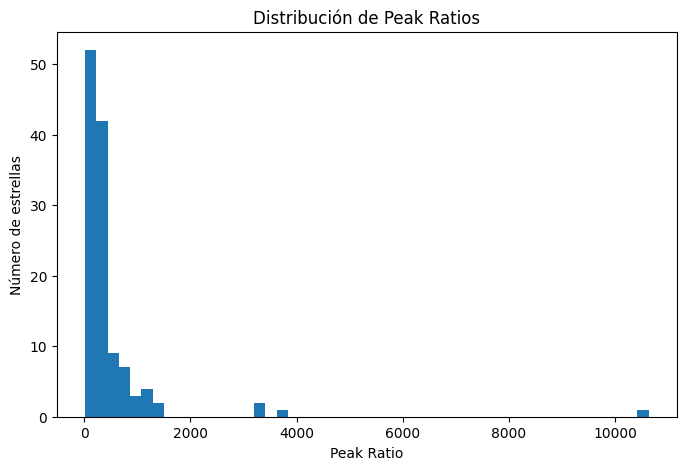

In [22]:
all_ratios = [
    r["peak_ratio"]
    for r in results
]

plt.figure(figsize=(8,5))

plt.hist(all_ratios, bins=50)

plt.xlabel("Peak Ratio")

plt.ylabel("Número de estrellas")

plt.title("Distribución de Peak Ratios")

plt.show()

In [23]:
def plot_star_summary(
    result,
    index=None,
    save_path=None
):

    t = result["t"]
    y = result["y"]

    frequency = result["frequency"]
    power = result["power"]

    ls_period = result["ls_period"]

    analysis_type = result["analysis_type"]

    star_id = result["id"]

    # --------------------------------------------------------
    # Con mínima entropía
    # --------------------------------------------------------

    if analysis_type == "LS + Minimum Entropy":

        me_period = result["me_period"]

        entropy_grid = result["entropy_grid"]

        smooth_entropy = result["smooth_entropy"]

        fig, axs = plt.subplots(
            1,
            4,
            figsize=(20,4)
        )

    else:

        fig, axs = plt.subplots(
            1,
            3,
            figsize=(15,4)
        )

    # --------------------------------------------------------
    # Curva de luz
    # --------------------------------------------------------

    axs[0].scatter(t, y, s=10)

    axs[0].invert_yaxis()

    axs[0].set_xlabel("Tiempo")

    axs[0].set_ylabel("Magnitud")

    axs[0].set_title("Curva de luz")

    # --------------------------------------------------------
    # Lomb-Scargle
    # --------------------------------------------------------

    axs[1].plot(frequency, power)

    axs[1].set_xlabel("Frecuencia")

    axs[1].set_ylabel("Potencia")

    axs[1].set_title("Lomb-Scargle")

    # --------------------------------------------------------
    # Con mínima entropía
    # --------------------------------------------------------

    if analysis_type == "LS + Minimum Entropy":

        axs[2].plot(
            entropy_grid,
            smooth_entropy
        )

        axs[2].invert_yaxis()

        axs[2].set_xlabel("Periodo")

        axs[2].set_ylabel("Entropía")

        axs[2].set_title("Mínima Entropía")

        phase = compute_phase(
            t,
            me_period
        )

        phase_title = f"P = {me_period:.4f}"

        phase_axis = axs[3]

    # --------------------------------------------------------
    # Solo LS
    # --------------------------------------------------------

    else:

        phase = compute_phase(
            t,
            ls_period
        )

        phase_title = f"P = {ls_period:.4f}"

        phase_axis = axs[2]

    # --------------------------------------------------------
    # Curva plegada
    # --------------------------------------------------------

    phase2 = np.concatenate([
        phase,
        phase + 1
    ])

    y2 = np.concatenate([
        y,
        y
    ])

    phase_axis.scatter(
        phase2,
        y2,
        s=10
    )

    phase_axis.invert_yaxis()

    phase_axis.set_xlabel("Fase")

    phase_axis.set_ylabel("Magnitud")

    phase_axis.set_title(phase_title)

    # --------------------------------------------------------

    plt.suptitle(
        f"{analysis_type} | ID {star_id}",
        fontsize=14
    )

    plt.tight_layout()

    if save_path is not None:

        plt.savefig(
            save_path,
            dpi=150
        )

        plt.close()

    else:

        plt.show()

In [25]:
# ============================================================
# CELDA 11 — GUARDAR FIGURAS
# ============================================================

output_dir = "HDF5_Results"

os.makedirs(
    output_dir,
    exist_ok=True
)

# ------------------------------------------------------------
# SOLO guardar estrellas seleccionadas
# ------------------------------------------------------------

for i, r in enumerate(selected_stars, start=1):

    filename = (
        f"{output_dir}/Star_{i}.png"
    )

    plot_star_summary(
        r,
        index=i,
        save_path=filename
    )

print("✅ Gráficas guardadas.")

✅ Gráficas guardadas.


In [ ]:
# ============================================================
# CELDA 12 — CATÁLOGO FINAL
# ============================================================

catalog_rows = []

for i, r in enumerate(selected_stars):

    row = {

        "estrella": i + 1,

        "id": r["id"],

        "analysis_type":
        r["analysis_type"],

        "ls_period":
        r["ls_period"],

        "fap":
        r["fap"],

        "peak_ratio":
        r["peak_ratio"]
    }

    # --------------------------------------------------------
    # Si tiene mínima entropía
    # --------------------------------------------------------

    if r["analysis_type"] == "LS + Minimum Entropy":

        row["me_period"] = r["me_period"]

        row["min_entropy"] = r["min_entropy"]

    else:

        row["me_period"] = np.nan

        row["min_entropy"] = np.nan

    catalog_rows.append(row)

# ------------------------------------------------------------

df = pd.DataFrame(catalog_rows)

df.to_csv(
    f"{output_dir}/catalogo_estrellas.csv",
    index=False
)

print("✅ Catálogo guardado.")

✅ Catálogo guardado.
